In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

--- Initial Raw Shape: (1000, 4) ---
Missing Values Before Cleaning:
Date        0
Product    50
Region      0
Sales      80
dtype: int64

--- Processed Shape: (950, 4) ---
Missing Values After Cleaning:
Date       0
Product    0
Region     0
Sales      0
dtype: int64

--- Region-Wise Total Performance ---
Region         Sales
 North 239926.743157
  West 157715.230825
  East 137013.422783
 South  86089.389673 

Best Performing Region: North

--- Monthly Growth Metrics ---
YearMonth         Sales  Monthly_Growth_Rate (%)
  2026-01 150009.105749                      NaN
  2026-02 146950.387741                -2.039022
  2026-03 171150.800371                16.468424
  2026-04 152634.492577               -10.818709 



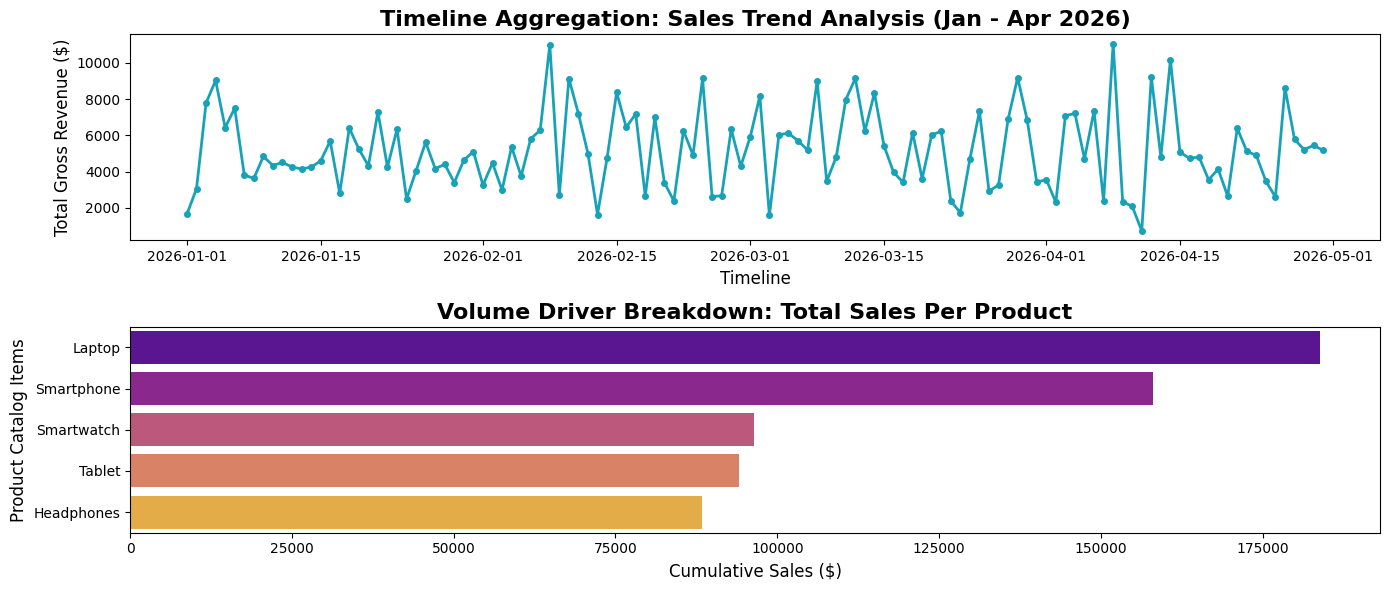

In [10]:
np.random.seed(101)
dates = pd.date_range(start="2026-01-01", end="2026-04-30", freq="D")
products = ["Laptop", "Smartphone", "Tablet", "Smartwatch", "Headphones"]
regions = ["North", "East", "West", "South"]

# Generate random base data
raw_data = {
    "Date": np.random.choice(dates, size=1000),
    "Product": np.random.choice(products, size=1000, p=[0.3, 0.25, 0.15, 0.15, 0.15]),
    "Region": np.random.choice(regions, size=1000, p=[0.4, 0.2, 0.25, 0.15]),
    "Sales": np.random.uniform(50, 1200, size=1000)
}
df = pd.DataFrame(raw_data)

# Inject random missing values (NaNs) into Product and Sales columns to simulate real-world data
df.loc[df.sample(frac=0.05).index, 'Product'] = np.nan
df.loc[df.sample(frac=0.08).index, 'Sales'] = np.nan

print(f"--- Initial Raw Shape: {df.shape} ---")
print(f"Missing Values Before Cleaning:\n{df.isnull().sum()}\n")

# DATA CLEANING STEP

#Drop records where Product are missing
df.dropna(subset=['Product'], inplace=True)

# Impute missing numerical Sales values with the median of that specific product category
df['Sales'] = df.groupby('Product')['Sales'].transform(lambda x: x.fillna(x.median()))

print(f"--- Processed Shape: {df.shape} ---")
print(f"Missing Values After Cleaning:\n{df.isnull().sum()}\n")

# Total Sales per Product
product_sales = df.groupby('Product')['Sales'].sum().reset_index().sort_values(by='Sales', ascending=False)

# Region-wise Performance
region_sales = df.groupby('Region')['Sales'].sum().reset_index().sort_values(by='Sales', ascending=False)
best_performing_region = region_sales.iloc[0]['Region']

#monthly Growth annalysis
df['YearMonth'] = df['Date'].dt.to_period('M')
monthly_sales = df.groupby('YearMonth')['Sales'].sum().reset_index()
monthly_sales['Monthly_Growth_Rate (%)'] = monthly_sales['Sales'].pct_change() * 100

print("--- Region-Wise Total Performance ---")
print(region_sales.to_string(index=False), "\n")
print(f"Best Performing Region: {best_performing_region}\n")

print("--- Monthly Growth Metrics ---")
print(monthly_sales.to_string(index=False), "\n")

# VISUALIZATION SYSTEM

fig, axes = plt.subplots(2,1, figsize=(14, 6))

# Chart 1: Sales Trends (Line Chart)
daily_trend = df.groupby('Date')['Sales'].sum().reset_index()
axes[0].plot(daily_trend['Date'], daily_trend['Sales'], color='#17a2b8', linewidth=2, label='Daily Revenue',  marker='o', markersize=4)
axes[0].set_title("Timeline Aggregation: Sales Trend Analysis (Jan - Apr 2026)", fontsize=16, fontweight='bold')
axes[0].set_xlabel("Timeline", fontsize=12)
axes[0].set_ylabel("Total Gross Revenue ($)", fontsize=12)

# Chart 2: Top Products Performance (Bar Chart)
sns.barplot(x='Sales', y='Product', data=product_sales, ax=axes[1], palette='plasma', hue='Product')
axes[1].set_title("Volume Driver Breakdown: Total Sales Per Product", fontsize=16, fontweight='bold')
axes[1].set_xlabel("Cumulative Sales ($)", fontsize=12)
axes[1].set_ylabel("Product Catalog Items", fontsize=12)

plt.tight_layout()
plt.show()